In [2]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [3]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [5]:
ks, _, iGarr = gvectors("./LDA/BN44NC-0.0");
iGarr_gamma = np.array(iGarr[1]);

In [12]:
Ckb = return_cg("./LDA/BN44NC-0.0", ks, iGarr, [0, 0, 0], 64, 128, Val('d'));

In [13]:
wfn = JJDFTX.real_space_wfn(Ckb, iGarr_gamma, [80, 80, 168])
wfn_squared = (abs.(wfn)).^2
wfn_squared *= length(wfn_squared); # Make it so wfn squared is probability density at each point

In [14]:
sum(wfn_squared)*12473.8/length(wfn_squared)

1.0000018092818053

In [15]:
splits = Float64[]
x = Float64[]
for i in 1:41
    println("Iteration: $i"); flush(stdout)
    charge = round(-1+(i-1)/40, digits=3)

    filename_eigenvals = "./LDA/BN44NC-$(charge).eigenvals"
    
    filename_nup = "./LDA/BN44NC-$(charge).n_up"
    
    filename_ndn = "./LDA/BN44NC-$(charge).n_dn"
    
    n_up = np.fromfile(filename_nup)
    n_dn = np.fromfile(filename_ndn)
        
    n_up = np.reshape(n_up, [80, 80, 168])
    n_dn = np.reshape(n_dn, [80, 80, 168])

    diff = abs(sum((n_up.^(1/3) - n_dn.^(1/3)).*wfn_squared))*12473.8/length(n_dn)

    push!(x, diff)
    data = JJDFTX.bandstruct_properties(filename_eigenvals, 128, 19, spin=2);
    push!(splits, abs(mean(data[2][64]) - mean(data[1][64])))
end

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41


In [16]:
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = true;

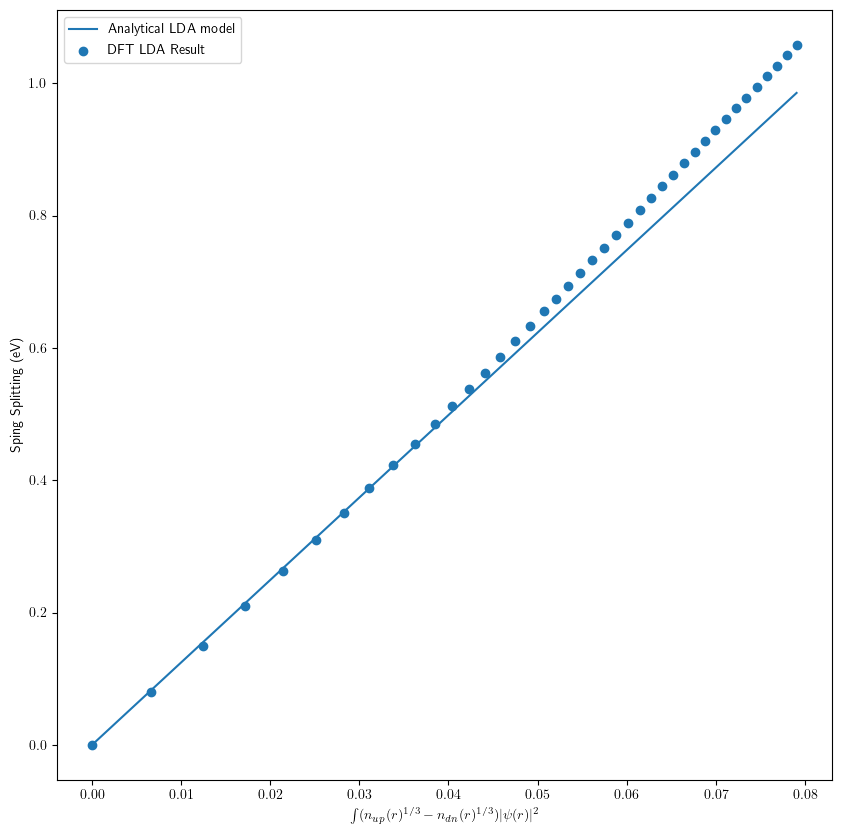

PyObject <matplotlib.legend.Legend object at 0x7f83dc66d400>

In [17]:
figure(figsize=(10, 10))
scatter(x, splits, label="DFT LDA Result")

plot(x, x*0.458*1/eV, label="Analytical LDA model")
ylabel("Sping Splitting (eV)")

xlabel(L"\int (n_{up}(r)^{1/3}-n_{dn}(r)^{1/3})|\psi(r)|^2")
legend()

In [16]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/BN44NC/Doping"